In [3]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Aesthetic constants ───────────────────────────────────────────────────────
BG   = "#f6f1eb"
DARK = "#2f241f"
EDGE = "#3d3128"
GRID = "#8b6f5a"

DOMAIN_COLORS = {
    "EWT":   "#EFA6C1",
    "CONLL": "#8FD3B6",
    "WIESP": "#F4B183",
}

EVALSET_TO_DOMAIN = {
    "ewt_dev":    "EWT",
    "conll_test": "CONLL",
    "astro_test": "WIESP",
}

EVALSET_LABELS = {
    "ewt_dev":    "EWT Dev",
    "conll_test": "CoNLL Test",
    "astro_test": "WIESP Test",
}

F1_COL = "entity_f1_micro"

plt.rcParams.update({
    "font.family":       "DejaVu Serif",
    "axes.facecolor":    BG,
    "figure.facecolor":  BG,
    "axes.edgecolor":    EDGE,
    "axes.linewidth":    0.8,
    "text.color":        DARK,
    "axes.labelcolor":   DARK,
    "xtick.color":       DARK,
    "ytick.color":       DARK,
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Paths: this notebook is intended to live in Visualizations/ ───────────────
RUNS_DIR = Path("../runs")

SCIBERT_CONLL = RUNS_DIR / "summary_conll_scibert.csv"
SCIBERT_ASTRO = RUNS_DIR / "summary_astro_scibert.csv"

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

print("SciBERT CoNLL summary:", SCIBERT_CONLL.resolve())
print("Exists:", SCIBERT_CONLL.exists())
print("SciBERT Astro summary:", SCIBERT_ASTRO.resolve())
print("Exists:", SCIBERT_ASTRO.exists())


SciBERT CoNLL summary: C:\Users\rudra\OneDrive - ITU\Cross_domain_NER_Project_2026\runs\summary_conll_scibert.csv
Exists: True
SciBERT Astro summary: C:\Users\rudra\OneDrive - ITU\Cross_domain_NER_Project_2026\runs\summary_astro_scibert.csv
Exists: True


In [4]:
def load_iter(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    # Compute target fraction: percentage of target pool injected.
    # n_target_examples == 0 at iteration 0.
    # max(n_target_examples) == full target pool.
    pool_size = df["n_target_examples"].max()
    df["target_pct"] = df["n_target_examples"] / pool_size * 100

    return df

# SciBERT iterative summaries ONLY
scibert_conll_df = load_iter(SCIBERT_CONLL)
scibert_astro_df = load_iter(SCIBERT_ASTRO)

print("SciBERT CoNLL shape:", scibert_conll_df.shape)
print("SciBERT Astro shape:", scibert_astro_df.shape)
print("CoNLL seeds:", sorted(scibert_conll_df["seed"].unique()))
print("Astro seeds:", sorted(scibert_astro_df["seed"].unique()))


SciBERT CoNLL shape: (60, 84)
SciBERT Astro shape: (60, 84)
CoNLL seeds: [42]
Astro seeds: [42]


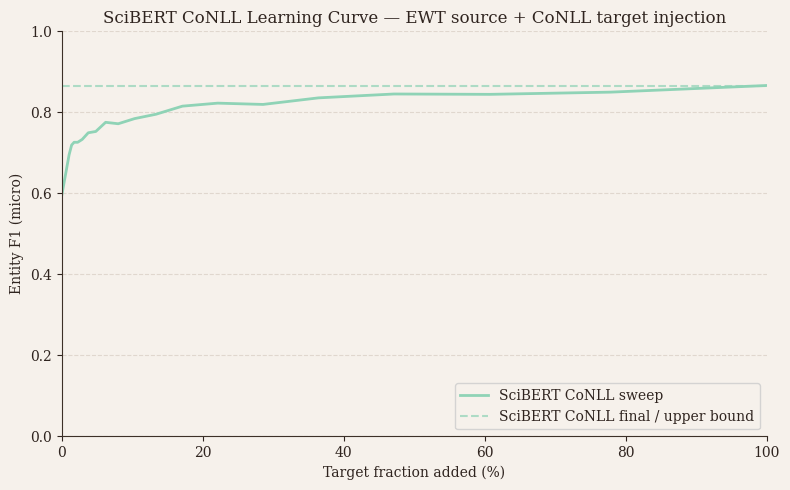

In [5]:
# Plot 1: SciBERT CoNLL learning curve
subset = scibert_conll_df[scibert_conll_df["eval_set"] == "conll_test"]
grouped = subset.groupby("target_pct")[F1_COL].agg(["mean", "std"]).reset_index()

color = DOMAIN_COLORS["CONLL"]

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.plot(
    grouped["target_pct"],
    grouped["mean"],
    color=color,
    linewidth=2,
    label="SciBERT CoNLL sweep"
)

# Only show std shading if there is more than one seed
if grouped["std"].notna().any():
    ax.fill_between(
        grouped["target_pct"],
        grouped["mean"] - grouped["std"].fillna(0),
        grouped["mean"] + grouped["std"].fillna(0),
        color=color,
        alpha=0.25,
        label="±1 std"
    )

ax.axhline(
    grouped["mean"].max(),
    color=color,
    linestyle="--",
    alpha=0.7,
    label="SciBERT CoNLL final / upper bound"
)

ax.grid(axis="y", linestyle="--", alpha=0.20, color=GRID)
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.set_xlabel("Target fraction added (%)")
ax.set_ylabel("Entity F1 (micro)")
ax.set_title("SciBERT CoNLL Learning Curve — EWT source + CoNLL target injection")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "scibert_conll_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()


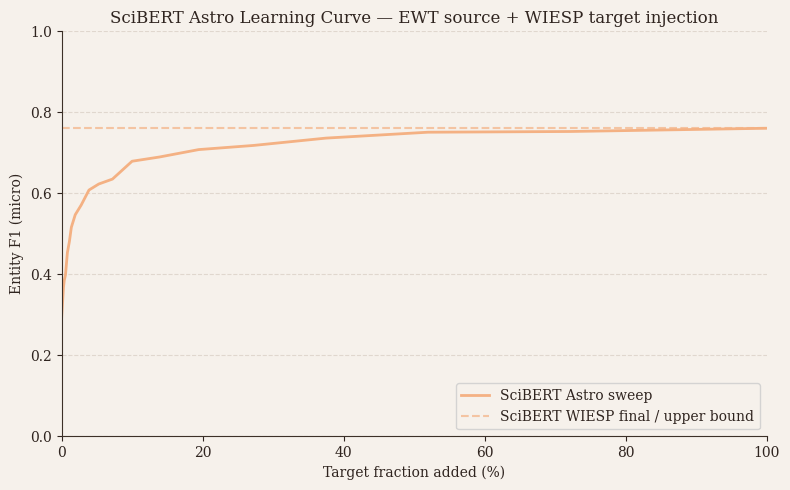

In [6]:
# Plot 2: SciBERT Astro learning curve
subset = scibert_astro_df[scibert_astro_df["eval_set"] == "astro_test"]
grouped = subset.groupby("target_pct")[F1_COL].agg(["mean", "std"]).reset_index()

color = DOMAIN_COLORS["WIESP"]

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.plot(
    grouped["target_pct"],
    grouped["mean"],
    color=color,
    linewidth=2,
    label="SciBERT Astro sweep"
)

# Only show std shading if there is more than one seed
if grouped["std"].notna().any():
    ax.fill_between(
        grouped["target_pct"],
        grouped["mean"] - grouped["std"].fillna(0),
        grouped["mean"] + grouped["std"].fillna(0),
        color=color,
        alpha=0.25,
        label="±1 std"
    )

ax.axhline(
    grouped["mean"].max(),
    color=color,
    linestyle="--",
    alpha=0.7,
    label="SciBERT WIESP final / upper bound"
)

ax.grid(axis="y", linestyle="--", alpha=0.20, color=GRID)
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.set_xlabel("Target fraction added (%)")
ax.set_ylabel("Entity F1 (micro)")
ax.set_title("SciBERT Astro Learning Curve — EWT source + WIESP target injection")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "scibert_astro_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()


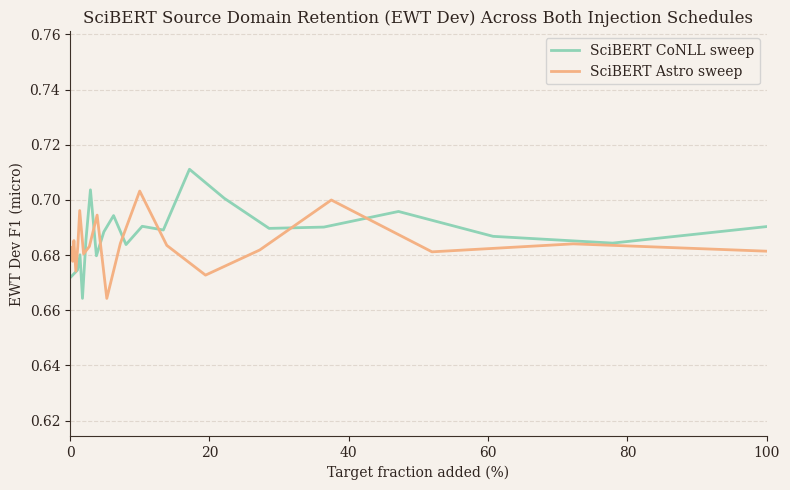

In [7]:
# Plot 3: SciBERT EWT source retention
scibert_conll_ewt = (
    scibert_conll_df[scibert_conll_df["eval_set"] == "ewt_dev"]
    .groupby("target_pct")[F1_COL]
    .agg(["mean", "std"])
    .reset_index()
)

scibert_astro_ewt = (
    scibert_astro_df[scibert_astro_df["eval_set"] == "ewt_dev"]
    .groupby("target_pct")[F1_COL]
    .agg(["mean", "std"])
    .reset_index()
)

all_means = pd.concat([scibert_conll_ewt["mean"], scibert_astro_ewt["mean"]])
y_min = all_means.min() - 0.05
y_max = all_means.max() + 0.05

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

conll_color = DOMAIN_COLORS["CONLL"]
wiesp_color = DOMAIN_COLORS["WIESP"]

ax.plot(
    scibert_conll_ewt["target_pct"],
    scibert_conll_ewt["mean"],
    color=conll_color,
    linewidth=2,
    label="SciBERT CoNLL sweep"
)

if scibert_conll_ewt["std"].notna().any():
    ax.fill_between(
        scibert_conll_ewt["target_pct"],
        scibert_conll_ewt["mean"] - scibert_conll_ewt["std"].fillna(0),
        scibert_conll_ewt["mean"] + scibert_conll_ewt["std"].fillna(0),
        color=conll_color,
        alpha=0.2
    )

ax.plot(
    scibert_astro_ewt["target_pct"],
    scibert_astro_ewt["mean"],
    color=wiesp_color,
    linewidth=2,
    label="SciBERT Astro sweep"
)

if scibert_astro_ewt["std"].notna().any():
    ax.fill_between(
        scibert_astro_ewt["target_pct"],
        scibert_astro_ewt["mean"] - scibert_astro_ewt["std"].fillna(0),
        scibert_astro_ewt["mean"] + scibert_astro_ewt["std"].fillna(0),
        color=wiesp_color,
        alpha=0.2
    )

ax.grid(axis="y", linestyle="--", alpha=0.20, color=GRID)
ax.set_xlim(0, 100)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Target fraction added (%)")
ax.set_ylabel("EWT Dev F1 (micro)")
ax.set_title("SciBERT Source Domain Retention (EWT Dev) Across Both Injection Schedules")
ax.legend(loc="upper right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "scibert_ewt_retention.png", dpi=300, bbox_inches="tight")
plt.show()


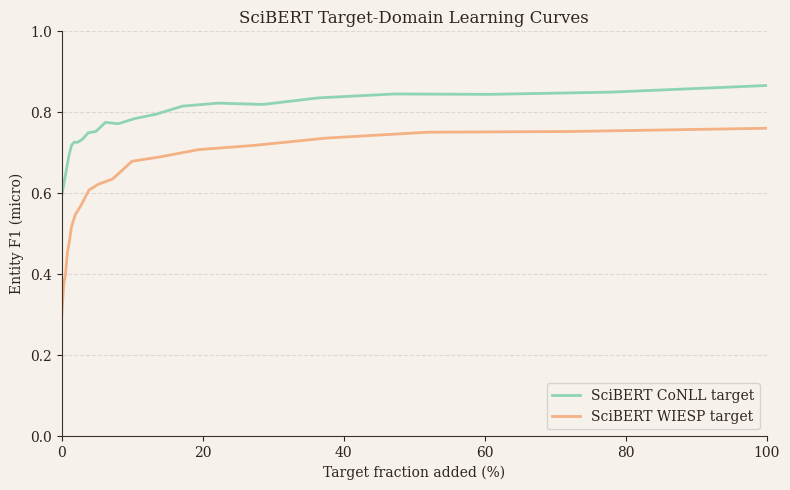

In [8]:
# Plot 4: SciBERT target-domain comparison
conll_target = (
    scibert_conll_df[scibert_conll_df["eval_set"] == "conll_test"]
    .groupby("target_pct")[F1_COL]
    .agg(["mean", "std"])
    .reset_index()
)

astro_target = (
    scibert_astro_df[scibert_astro_df["eval_set"] == "astro_test"]
    .groupby("target_pct")[F1_COL]
    .agg(["mean", "std"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.plot(
    conll_target["target_pct"],
    conll_target["mean"],
    color=DOMAIN_COLORS["CONLL"],
    linewidth=2,
    label="SciBERT CoNLL target"
)

ax.plot(
    astro_target["target_pct"],
    astro_target["mean"],
    color=DOMAIN_COLORS["WIESP"],
    linewidth=2,
    label="SciBERT WIESP target"
)

ax.grid(axis="y", linestyle="--", alpha=0.20, color=GRID)
ax.set_xlim(0, 100)
ax.set_ylim(0, 1)
ax.set_xlabel("Target fraction added (%)")
ax.set_ylabel("Entity F1 (micro)")
ax.set_title("SciBERT Target-Domain Learning Curves")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "scibert_target_domain_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
